<a href="https://colab.research.google.com/github/isadorapandas/data-science-visualizacao-de-dados/blob/main/Visualizacao_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/bibliotecas_visualizacao/refs/heads/main/Dados/imigrantes_canada.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 38 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   País        195 non-null    object
 1   Continente  195 non-null    object
 2   Região      195 non-null    object
 3   1980        195 non-null    int64 
 4   1981        195 non-null    int64 
 5   1982        195 non-null    int64 
 6   1983        195 non-null    int64 
 7   1984        195 non-null    int64 
 8   1985        195 non-null    int64 
 9   1986        195 non-null    int64 
 10  1987        195 non-null    int64 
 11  1988        195 non-null    int64 
 12  1989        195 non-null    int64 
 13  1990        195 non-null    int64 
 14  1991        195 non-null    int64 
 15  1992        195 non-null    int64 
 16  1993        195 non-null    int64 
 17  1994        195 non-null    int64 
 18  1995        195 non-null    int64 
 19  1996        195 non-null    int64 
 20  1997      

In [4]:
# analisar as tendências de imigração do Brasil ao longo dos anos
# vamos alterar o index do nosso dataframe para ser o país

df.set_index('País', inplace=True)

In [5]:
# vamos criar a variável anos igual à lista com os intervalos de ano. Ou seja, usamos a função list() e, nela,
# colocamos a função map(), porque vamos pedir para que os valores fiquem em string. Desse modo, vamos ter os valores como objetos e não como números
anos = list(map(str, range(1980, 2014)))

In [6]:
# queremos pegar somente os dados do Brasil
# Podemos usar a loc do Pandas para fazer isso, pois essa propriedade consegue pegar rótulos específicos dentro de um dataframe
brasil = df.loc['Brasil', anos]

In [7]:
brasil

,Brasil
1980,211
1981,220
1982,192
1983,139
1984,145
1985,130
1986,205
1987,244
1988,394
1989,650


In [8]:
brasil_dict = {'ano': brasil.index.tolist(), 'imigrantes': brasil.values.tolist()} # dicionário, que irá virar um dataframe
dados_brasil = pd.DataFrame(brasil_dict)

In [9]:
dados_brasil

,ano,imigrantes
0,1980,211
1,1981,220
2,1982,192
3,1983,139
4,1984,145
5,1985,130
6,1986,205
7,1987,244
8,1988,394
9,1989,650


In [10]:
import matplotlib.pyplot as plt

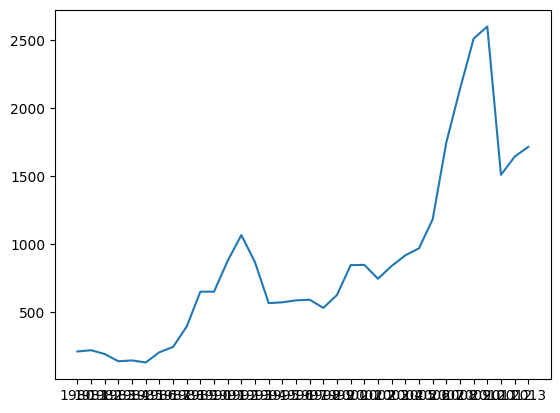

In [11]:
plt.plot(dados_brasil['ano'], dados_brasil['imigrantes'])

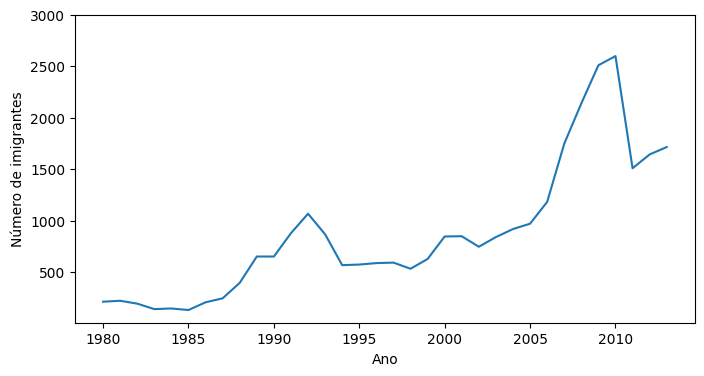

In [12]:
plt.figure(figsize=(8,4))
plt.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
plt.xlabel('Ano')
plt.ylabel('Número de imigrantes')
plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010']) # função xticks() que se refere as marcações do eixo x
plt.yticks([500, 1000, 1500, 2000, 2500, 3000]) # marcações do eixo y
plt.show()
# códigos escritos abaixo de plt.show() não serão executados, pois o Python interrompe a execução dos códigos

In [13]:
df_comparacao = df.loc[['Brasil', 'Argentina'], anos]
df_comparacao

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
País,,,,,,,,,,,,,,,,,,,,,
Brasil,211,220,192,139,145,130,205,244,394,650,...,917,969,1181,1746,2138,2509,2598,1508,1642,1714
Argentina,368,426,626,241,237,196,213,519,374,538,...,1591,1153,847,620,540,467,459,278,263,282


In [14]:
df_comparacao = df_comparacao.T # transpose

# Como resultado temos uma coluna com os anos e duas colunas para cada país contendo o número de imigrantes.

df_comparacao.head()

País,Brasil,Argentina
1980,211,368
1981,220,426
1982,192,626
1983,139,241
1984,145,237


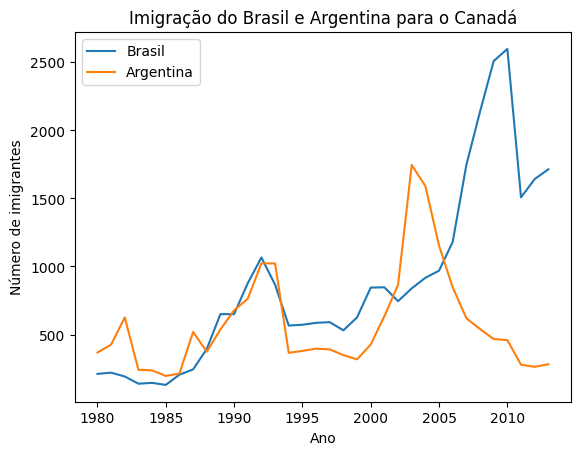

In [15]:
plt.plot(df_comparacao['Brasil'], label = 'Brasil')
plt.plot(df_comparacao['Argentina'], label ='Argentina')
plt.title('Imigração do Brasil e Argentina para o Canadá')
plt.xlabel('Ano')
plt.ylabel('Número de imigrantes')
plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
plt.legend()
plt.show()

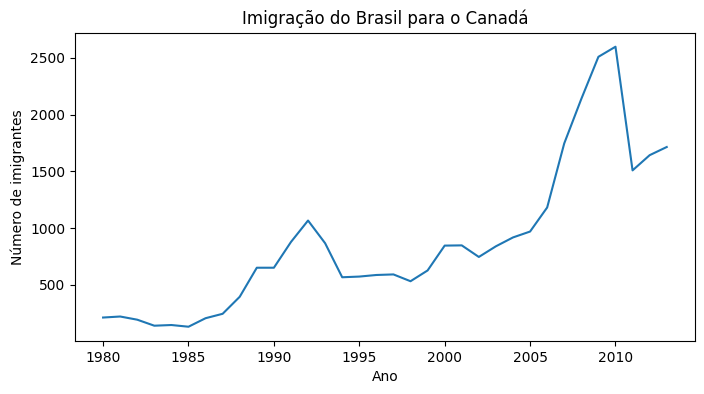

In [23]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
ax.set_title('Imigração do Brasil para o Canadá')
ax.set_xlabel('Ano')
ax.set_ylabel('Número de imigrantes')
ax.xaxis.set_major_locator(plt.MultipleLocator(5)) # com set_major_locator() conseguimos modificar o eixo x para o intervalo de 5 em 5 anos
plt.show()

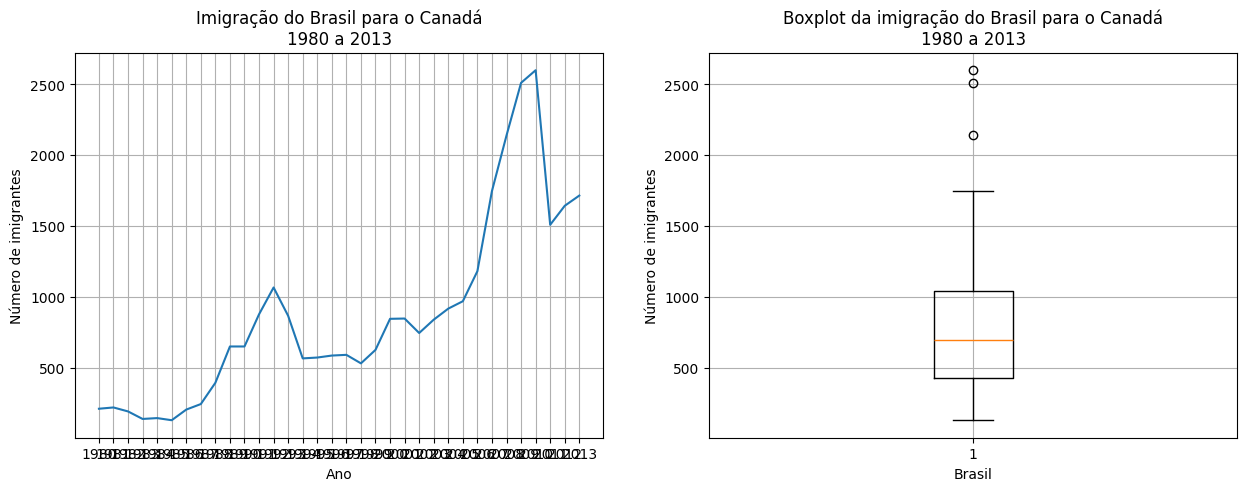

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5)) # criando dois subplots

# primeiro subplot
axs[0].plot(dados_brasil['ano'], dados_brasil['imigrantes'])
axs[0].set_title('Imigração do Brasil para o Canadá\n1980 a 2013')
axs[0].set_xlabel('Ano')
axs[0].set_ylabel('Número de imigrantes')
axs[0].xaxis.set_major_locator
axs[0].grid()

# segundo subplot
axs[1].boxplot(dados_brasil['imigrantes'])
axs[1].set_title('Boxplot da imigração do Brasil para o Canadá\n1980 a 2013')
axs[1].set_xlabel('Brasil')
axs[1].set_ylabel('Número de imigrantes')
axs[1].grid()

plt.show()


In [32]:
dados_brasil.describe()

,imigrantes
count,34.000000
mean,872.323529
std,663.401232
min,130.000000
25%,428.250000
50%,697.500000
75%,1041.750000
max,2598.000000


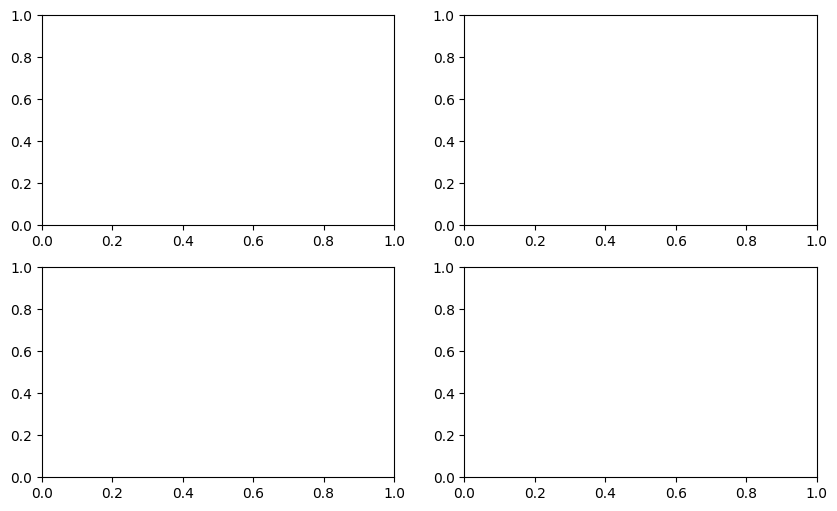

In [33]:
fig, axs = plt.subplots(2,2, figsize=(10,6)) # criando 4 subplots em 2 direções

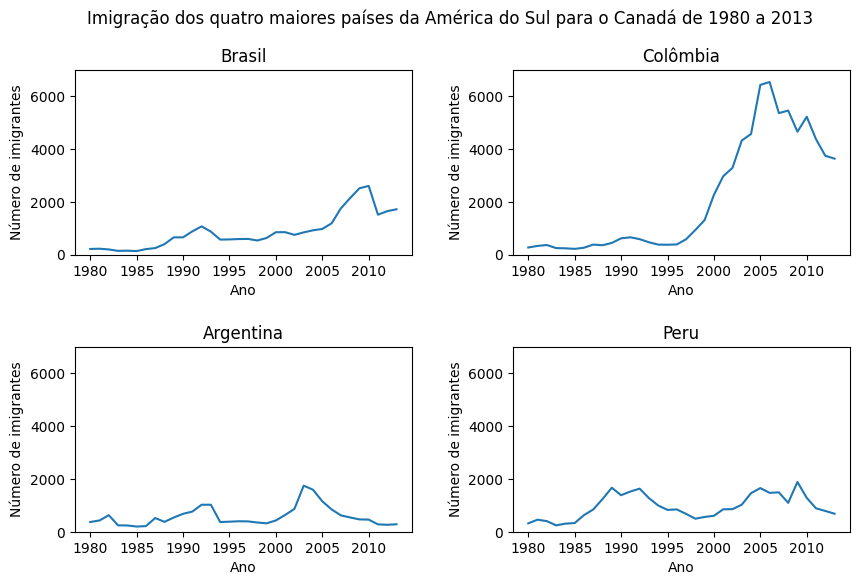

In [46]:
fig, axs = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Imigração dos quatro maiores países da América do Sul para o Canadá de 1980 a 2013')

# subplot da fileira 1 e coluna 1
axs[0,0].plot(df.loc['Brasil', anos])
axs[0,0].set_title('Brasil')

# subplot da fileira 1 e coluna 2
axs[0,1].plot(df.loc['Colômbia', anos])
axs[0,1].set_title('Colômbia')

# subplot da fileira 2 e coluna 1
axs[1,0].plot(df.loc['Argentina', anos])
axs[1,0].set_title('Argentina')

# subplot da fileira 2 e coluna 2
axs[1,1].plot(df.loc['Peru', anos])
axs[1,1].set_title('Peru')

# insere o intervalo de 5 em 5 anos para os 4 subplots
for ax in axs.flat:
  ax.xaxis.set_major_locator(plt.MultipleLocator(5))

# adiciona rótulo para os 4 sublplots
for ax in axs.flat:
  ax.set_xlabel('Ano')
  ax.set_ylabel('Número de imigrantes')

ymin = 0
ymax = 7000

# defini limite para o eixo y nos 4 subplots
for ax in axs.ravel():
  ax.set_ylim(ymin, ymax)

plt.show()

In [60]:
# criar uma figura com subplots que apresente a variação no número de vendas em quatro diferentes lojas ao longo de um ano

lojas = ['A', 'B', 'C', 'D']

vendas_2022 = {'Jan': [100, 80, 150, 50],
    'Fev': [120, 90, 170, 60],
    'Mar': [150, 100, 200, 80],
    'Abr': [180, 110, 230, 90],
    'Mai': [220, 190, 350, 200],
    'Jun': [230, 150, 280, 120],
    'Jul': [250, 170, 300, 140],
    'Ago': [260, 180, 310, 150],
    'Set': [240, 160, 290, 130],
    'Out': [220, 140, 270, 110],
    'Nov': [400, 220, 350, 190],
    'Dez': [300, 350, 400, 250]
}

df = pd.DataFrame(vendas_2022, index=lojas)

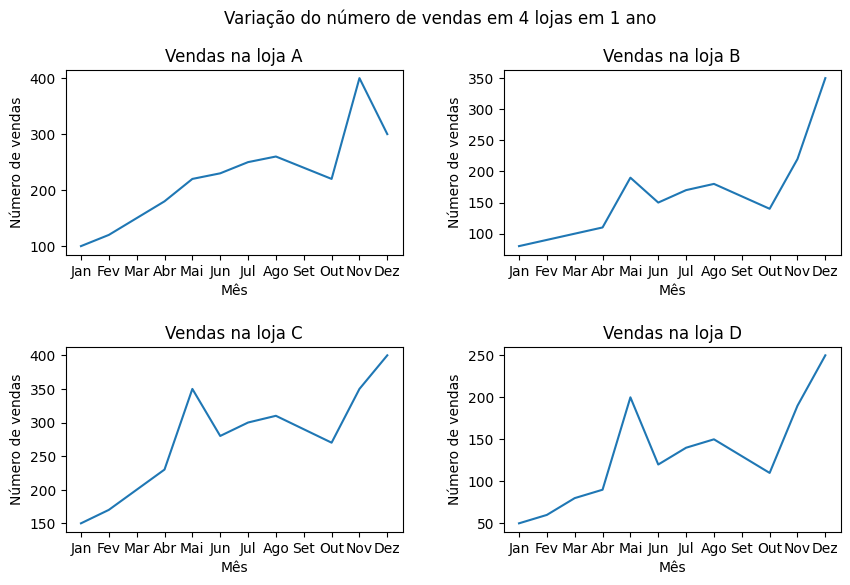

In [62]:
fig, axs = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Variação do número de vendas em 4 lojas em 1 ano')

# subplot da fileira 1 e coluna 1
axs[0,0].plot(df.loc['A'])
axs[0,0].set_title('Vendas na loja A')

# subplot da fileira 1 e coluna 2
axs[0,1].plot(df.loc['B'])
axs[0,1].set_title('Vendas na loja B')

# subplot da fileira 2 e coluna 1
axs[1,0].plot(df.loc['C'])
axs[1,0].set_title('Vendas na loja C')

# subplot da fileira 2 e coluna 2
axs[1,1].plot(df.loc['D'])
axs[1,1].set_title('Vendas na loja D')

# Adicionando rótulos para os eixos X e Y
for ax in axs.flat:
    ax.set_xlabel('Mês')
    ax.set_ylabel('Número de vendas')

plt.show()